# VAR autoregression for finance
This notebook keeps the workflow in one place: the bundled CSV lives in `data/`, figures and tables go to `out/`, and the reusable VAR logic stays in `xai_book.var_models`.

The notebook now compares a few small VAR systems first, then keeps a lecture-note-friendly two-series model for the main figures. In the exported plots, the first series is labeled `stock` and the second `mkt` to match the notation in the text. Forecast quality is measured with rolling one-step predictions rather than a blind multi-step rollout.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
while not (ROOT / "xai_book").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_DIR = Path("data")
NOTEBOOK_SLUG = "var_autoregression_finance"
OUT_DIR = Path("out") / NOTEBOOK_SLUG
OUT_DIR.mkdir(parents=True, exist_ok=True)

def out_path(filename: str) -> Path:
    return OUT_DIR / filename

In [2]:
from IPython.display import Markdown, display

from xai_book.plotting import display_and_save_figure
from xai_book.var_models import (
    DEFAULT_LECTURE_VAR_LABEL,
    LECTURE_VAR_CANDIDATES,
    compare_var_candidate_models,
    plot_candidate_comparison,
    plot_coefficient_heatmaps,
    plot_forecast_summary,
    plot_forecast_vs_actual,
    plot_irf_response,
    plot_lag_backtest,
    plot_one_step_contributions,
    plot_price_indices,
    run_var_finance_analysis,
)

DATA_PATH = DATA_DIR / "finance_var_sample_stocks.csv"

def show_and_save(fig, filename: str) -> Path:
    path = display_and_save_figure(fig, out_path(filename))
    print(f'saved: {path}')
    return path

def save_table(frame, filename: str) -> Path:
    path = out_path(filename)
    path.parent.mkdir(parents=True, exist_ok=True)
    frame.to_csv(path)
    print(f'saved: {path}')
    return path

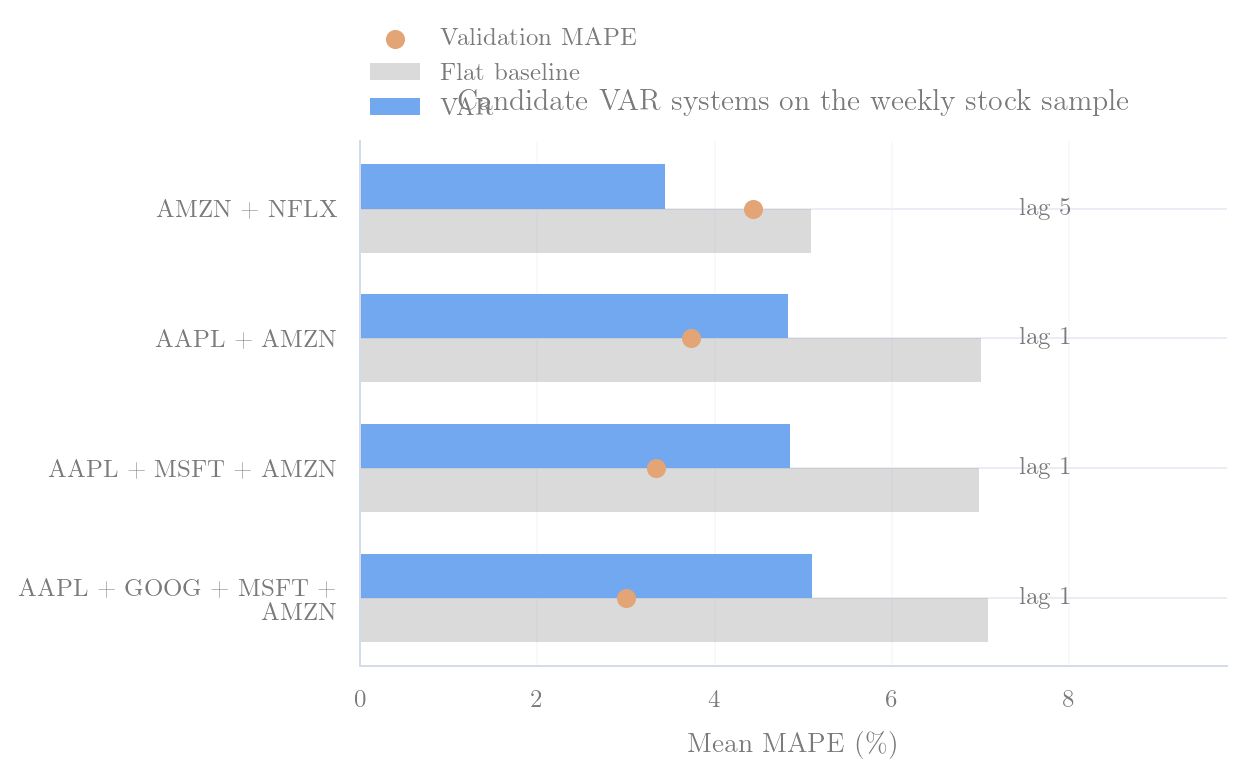

saved: out/var_autoregression_finance/var_candidate_comparison.pdf
saved: out/var_autoregression_finance/var_candidate_comparison.csv


**Lecture-note system:** `AAPL + AMZN`

**Lecture-note variables:** `stock` = `AAPL`, `mkt` = `AMZN`

selected lag: 1


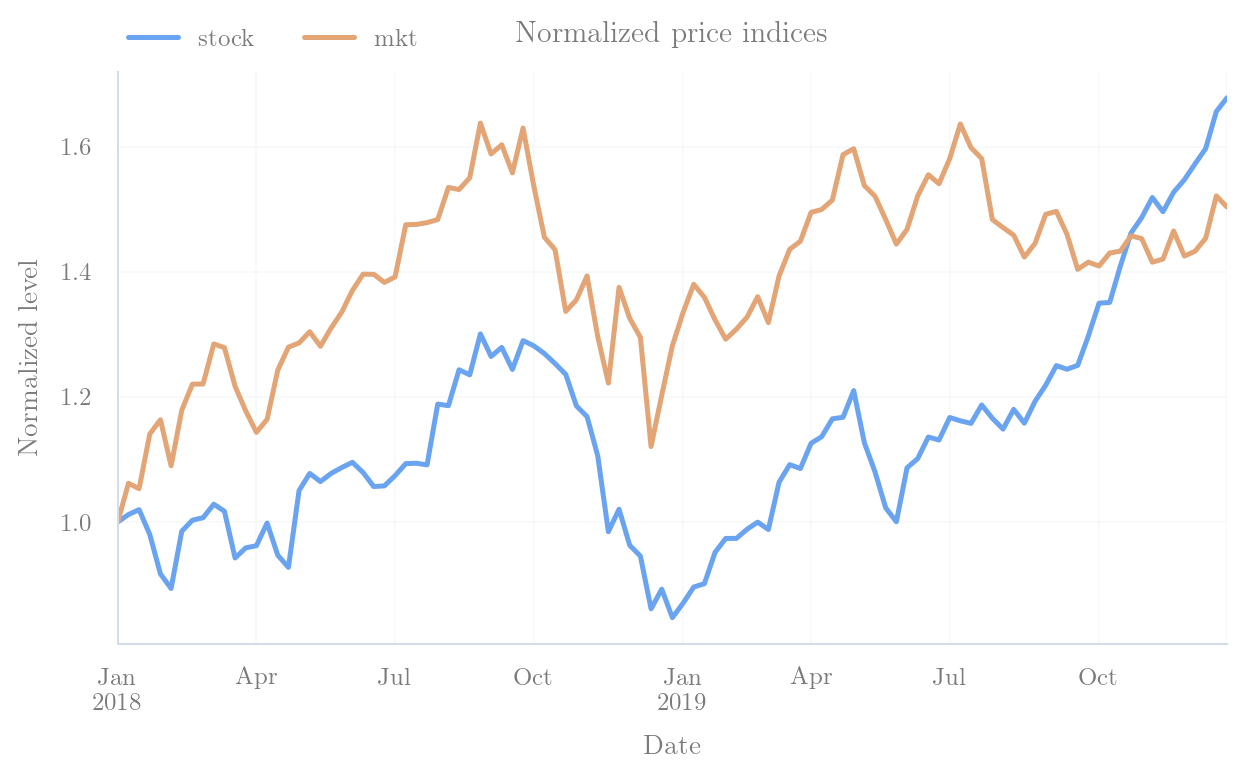

saved: out/var_autoregression_finance/var_price_indices.pdf


,candidate,tickers,n_series,selected_lag,validation_mape_pct,test_var_mape_pct,test_baseline_mape_pct,mape_gain_pct
0,AMZN + NFLX,"AMZN, NFLX",2,5,4.426901,3.442147,5.088132,1.645985
1,AAPL + AMZN,"AAPL, AMZN",2,1,3.727281,4.830090,7.002909,2.172819
2,AAPL + MSFT + AMZN,"AAPL, MSFT, AMZN",3,1,3.338296,4.845871,6.977206,2.131335
3,AAPL + GOOG + MSFT + AMZN,"AAPL, GOOG, MSFT, AMZN",4,1,3.005581,5.096604,7.076350,1.979745


,forecast_summary
mean_var_mae,0.074773
mean_var_rmse,0.083685
mean_var_mape_pct,4.830090
mean_baseline_mape_pct,7.002909
mean_mape_gain_pct,2.172819
validation_mape_pct,3.727281


,AAPL,AMZN
Date,,
2018-01-01,1.000000,1.000000
2018-01-08,1.011943,1.061881
2018-01-15,1.019771,1.053240
2018-01-22,0.980057,1.140676
2018-01-29,0.917143,1.163374


,adf_stat,adf_pvalue,stationary_at_5pct
series,,,
AAPL,0.162528,0.970080,False
AMZN,-2.914445,0.043694,True


,adf_stat,adf_pvalue,stationary_at_5pct
series,,,
AAPL,-6.029611,1.428385e-07,True
AMZN,-10.219334,5.376233e-18,True


,trace_stat,crit_90pct,crit_95pct,crit_99pct,reject_rank_at_95pct
r <= 0,12.415896,13.4294,15.4943,19.9349,False
r <= 1,0.205941,2.7055,3.8415,6.6349,False


estimated cointegration rank at 95%: 0


In [3]:
candidate_table, candidate_analyses = compare_var_candidate_models(
    data_path=DATA_PATH,
    candidates=LECTURE_VAR_CANDIDATES,
    n_test=12,
    validation_size=8,
    maxlags=6,
)
analysis = candidate_analyses[DEFAULT_LECTURE_VAR_LABEL]

show_and_save(plot_candidate_comparison(candidate_table), 'var_candidate_comparison.pdf')
save_table(candidate_table.set_index('candidate'), 'var_candidate_comparison.csv')

display(Markdown(f"**Lecture-note system:** `{DEFAULT_LECTURE_VAR_LABEL}`"))
display(Markdown(f"**Lecture-note variables:** `stock` = `{analysis['tickers'][0]}`, `mkt` = `{analysis['tickers'][1]}`"))
print(f"selected lag: {analysis['selected_lag']}")
show_and_save(plot_price_indices(analysis['prices'], series_labels=analysis['series_labels']), 'var_price_indices.pdf')

display(candidate_table)
display(analysis['forecast_summary'].to_frame())
display(analysis['prices'].head())
display(analysis['levels_adf'])
display(analysis['returns_adf'])
display(analysis['johansen_table'])
print(f"estimated cointegration rank at 95%: {analysis['estimated_rank_95']}")

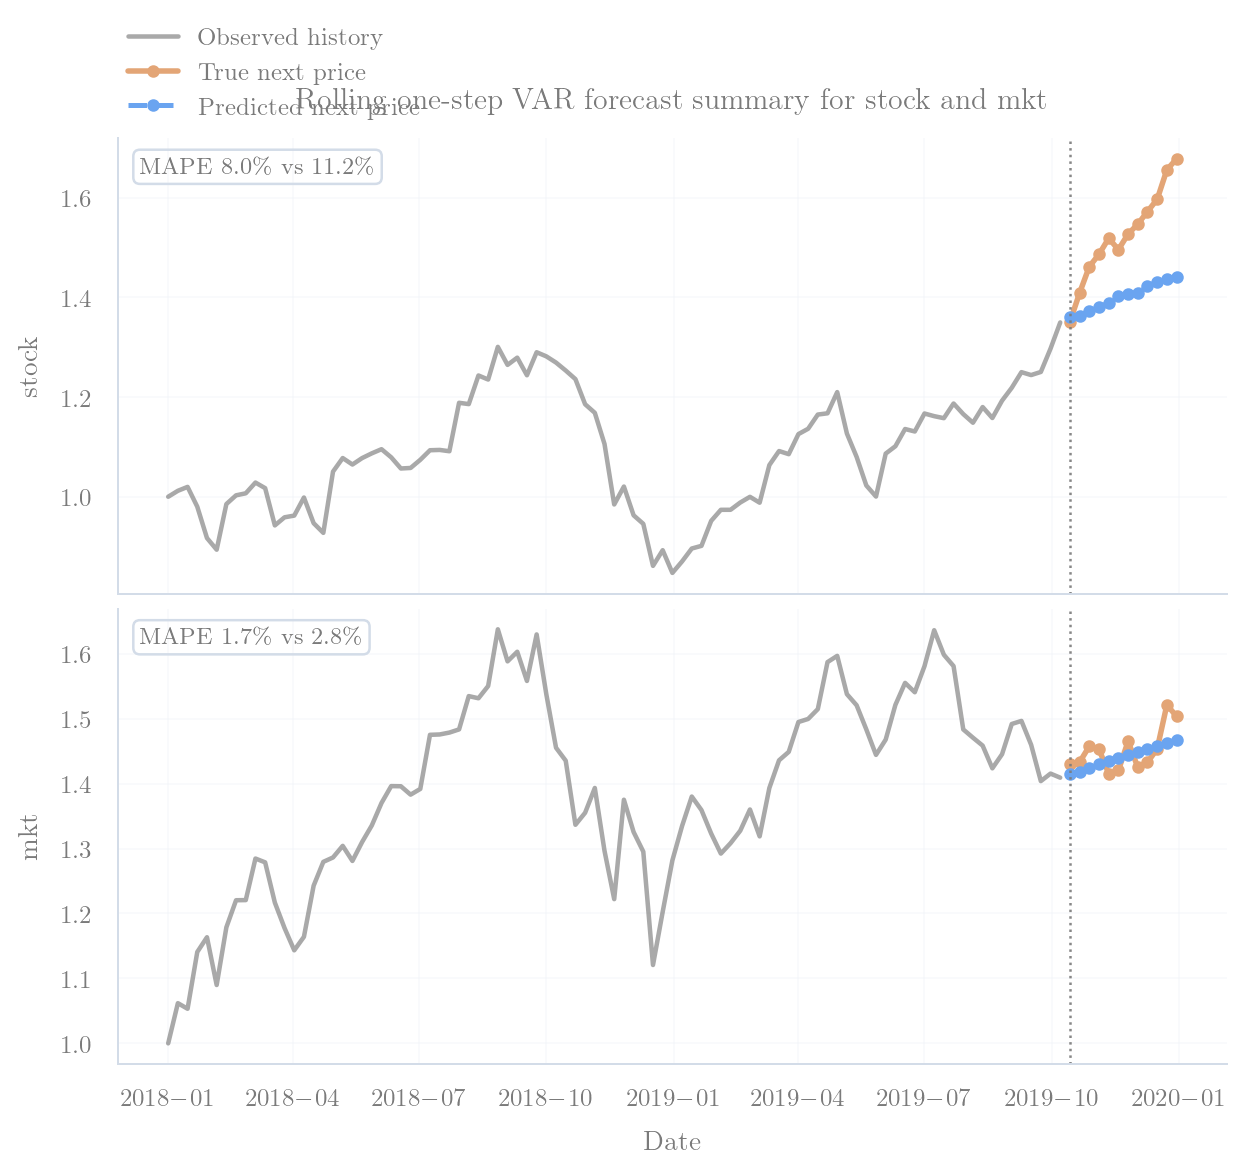

saved: out/var_autoregression_finance/var_forecast_summary.pdf


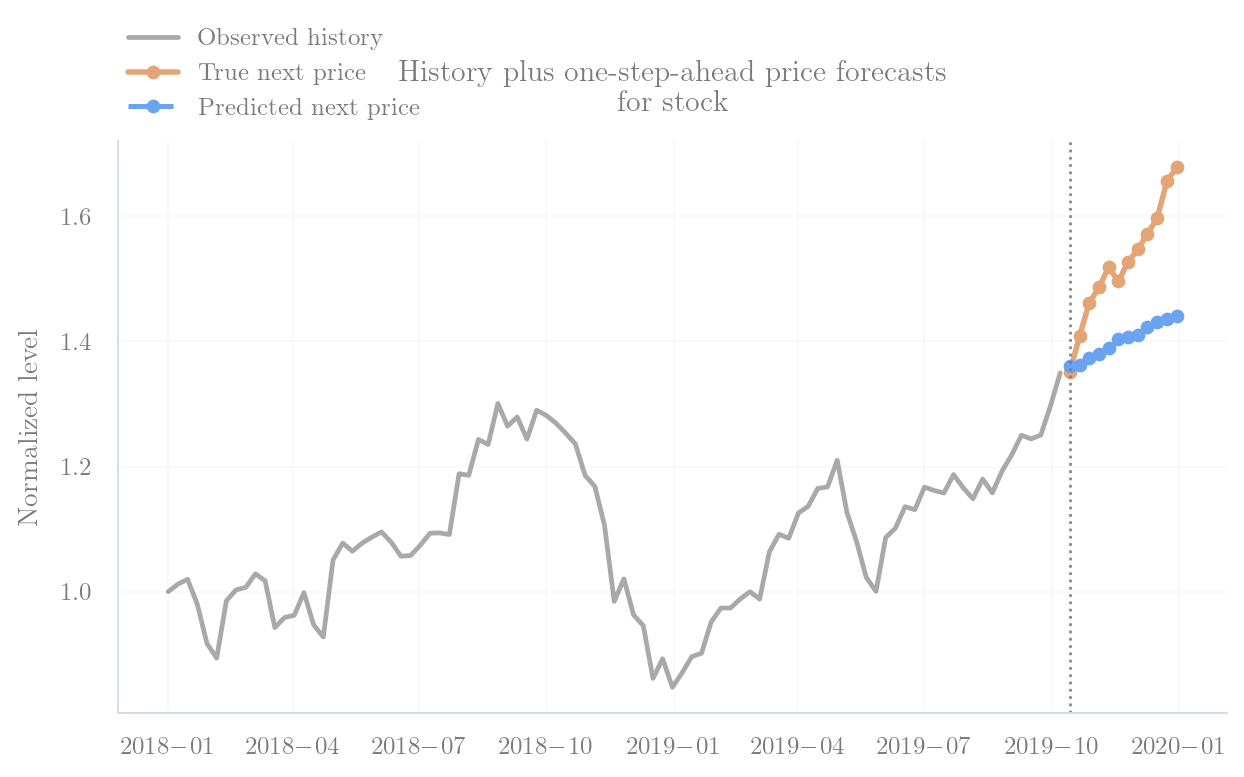

saved: out/var_autoregression_finance/var_forecast_aapl.pdf
saved: out/var_autoregression_finance/var_forecast_metrics.csv


VAR rolling one-step                     Flat baseline            \
                        MAE      RMSE  MAPE_pct           MAE      RMSE   
series                                                                    
AAPL               0.125337  0.139887  8.005131      0.175224  0.197273   
AMZN               0.024208  0.027483  1.655049      0.041751  0.052318   

                   
         MAPE_pct  
series             
AAPL    11.172956  
AMZN     2.832862

In [4]:
show_and_save(
    plot_forecast_summary(
        analysis['train_prices'],
        analysis['actual_prices'],
        analysis['pred_prices'],
        analysis['forecast_metrics'],
        title="Rolling one-step VAR forecast summary for stock and mkt",
        series_labels=analysis['series_labels'],
    ),
    'var_forecast_summary.pdf',
)
show_and_save(
    plot_forecast_vs_actual(
        analysis['train_prices'],
        analysis['actual_prices'],
        analysis['pred_prices'],
        target=analysis['target_plot'],
        series_labels=analysis['series_labels'],
    ),
    f"var_forecast_{analysis['target_plot'].lower()}.pdf",
)
save_table(analysis['forecast_metrics'], 'var_forecast_metrics.csv')

display(analysis['forecast_metrics'])

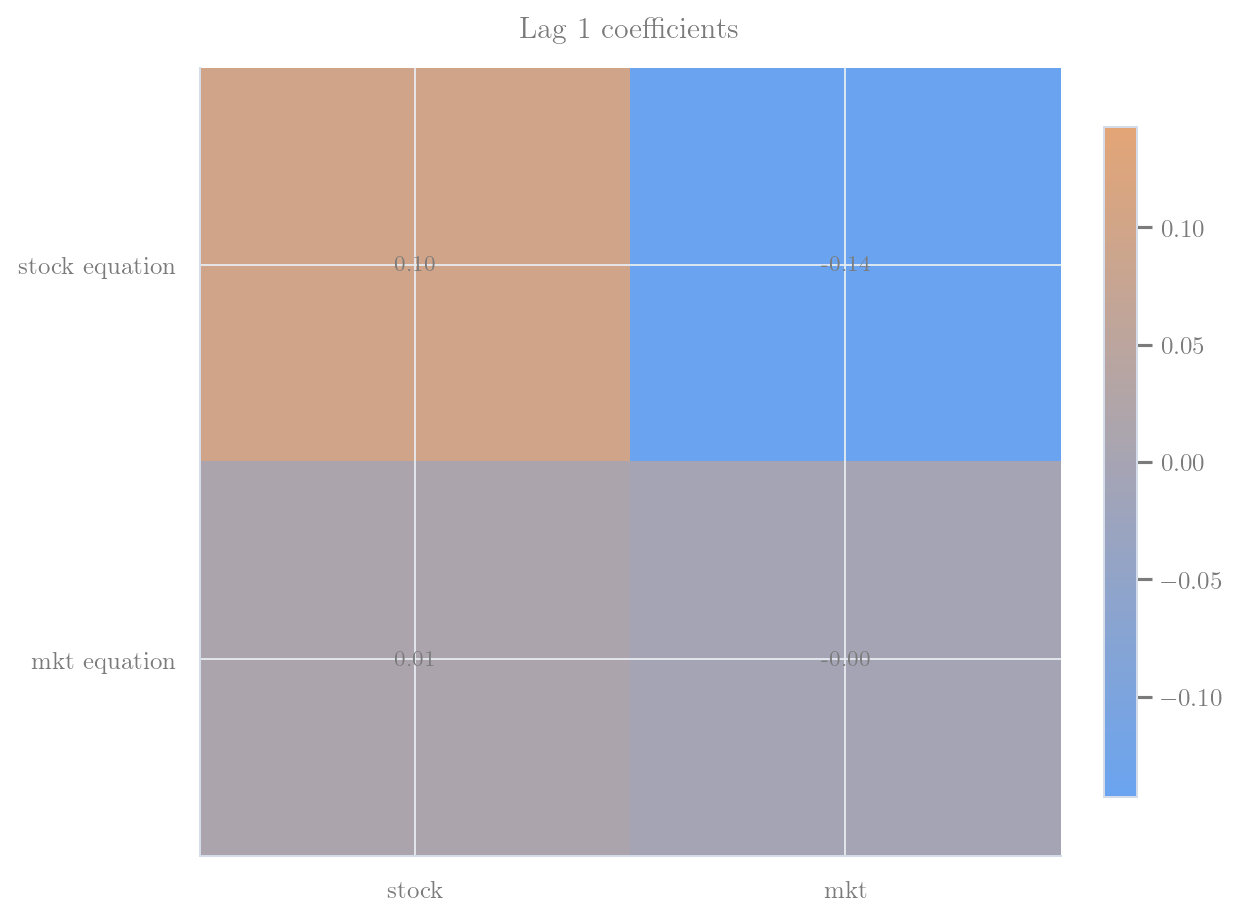

saved: out/var_autoregression_finance/var_coefficients.pdf


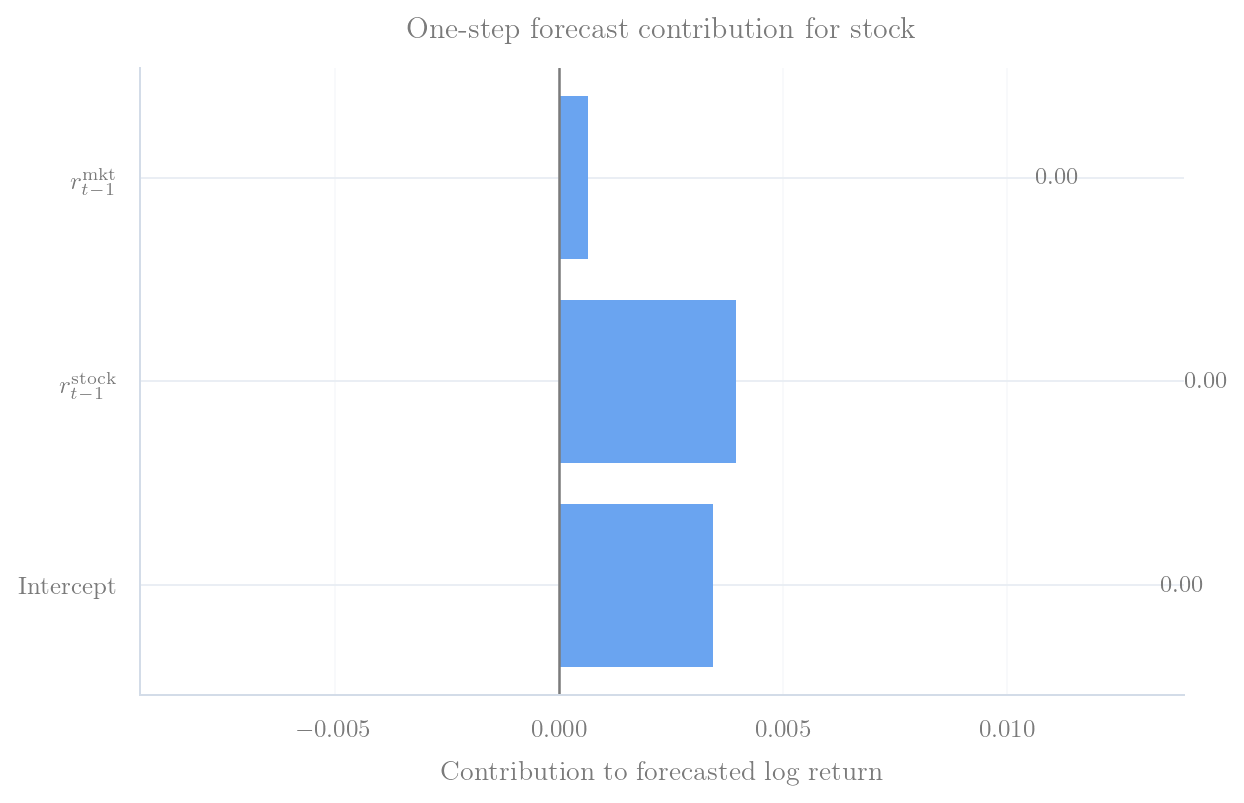

saved: out/var_autoregression_finance/var_local_contributions_aapl.pdf
saved: out/var_autoregression_finance/var_local_contributions.csv
lag 1 coefficients


,AAPL,AMZN
AAPL equation,0.099458,-0.142800
AMZN equation,0.012422,-0.004928


,AAPL one-step contribution
Intercept,0.003426
$r_{t-1}^{\mathrm{stock}}$,0.003951
$r_{t-1}^{\mathrm{mkt}}$,0.000636
Prediction,0.008013


In [5]:
show_and_save(plot_coefficient_heatmaps(analysis['coefficients'], series_labels=analysis['series_labels']), 'var_coefficients.pdf')
show_and_save(
    plot_one_step_contributions(
        analysis['local_contributions'],
        target=analysis['target_local'],
        series_labels=analysis['series_labels'],
    ),
    f"var_local_contributions_{analysis['target_local'].lower()}.pdf",
)
save_table(analysis['local_contributions'].to_frame(), 'var_local_contributions.csv')

for lag, frame in analysis['coefficients'].items():
    print(f'lag {lag} coefficients')
    display(frame)

display(analysis['local_contributions'].to_frame())